# matfile to pickle

In [17]:
import h5py
import numpy as np
import pandas as pd
import pickle
import os

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


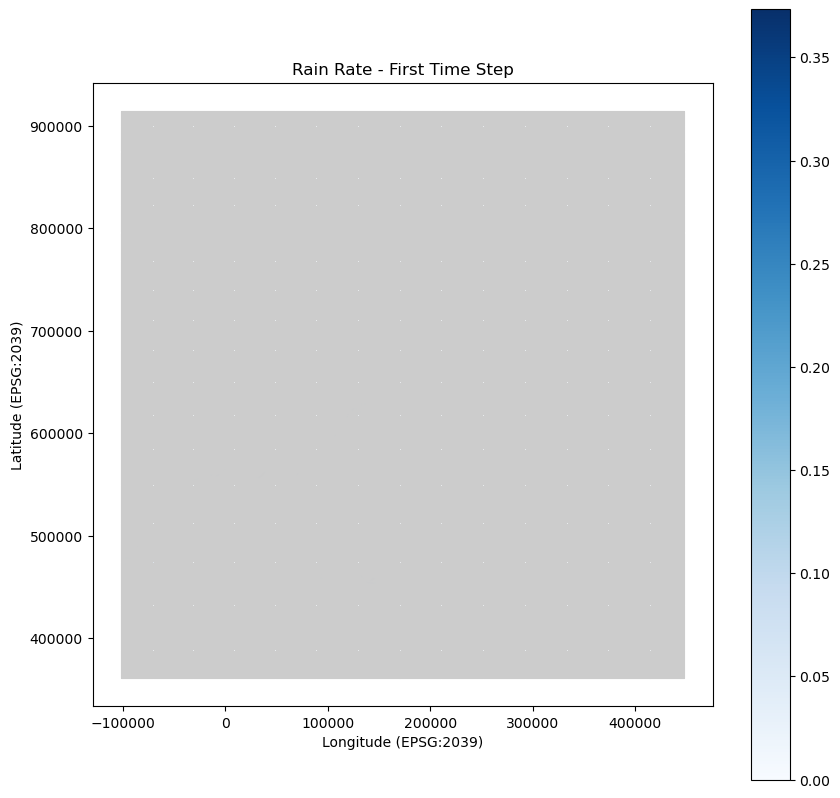

In [18]:
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pyproj import Transformer
from shapely.geometry import Polygon
from rasterio.transform import from_origin

# Function to convert a 2D array representing rainfall data into a GeoDataFrame
def rain_array_to_gdf(rain_array, x_coords, y_coords, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.
    """
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = x_coords[j]
            x_max = x_min + cellsize
            y_min = y_coords[i]
            y_max = y_min - cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'

# Read the .mat file
with h5py.File(mat_path, 'r') as file:
    # Extract data
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    
    # Print available keys
    print("Keys: %s" % file.keys())

# Define the coordinate reference system transformation using pyproj.Transformer
transformer = Transformer.from_crs("epsg:4326", "epsg:2039", always_xy=True)
lon_transformed, lat_transformed = transformer.transform(lon_data, lat_data)

# Ensure the transformed coordinates are correctly reshaped
lon_transformed = lon_transformed.reshape(lon_data.shape)
lat_transformed = lat_transformed.reshape(lat_data.shape)

# Define the cell size
cellsize = 1000  # Assuming a cell size of 1000 meters

# Create a GeoDataFrame for each time step
rain_rate_gdfs = [rain_array_to_gdf(rain_rate_data[t, :, :], lon_transformed[0, :], lat_transformed[:, 0], cellsize) for t in range(5)]




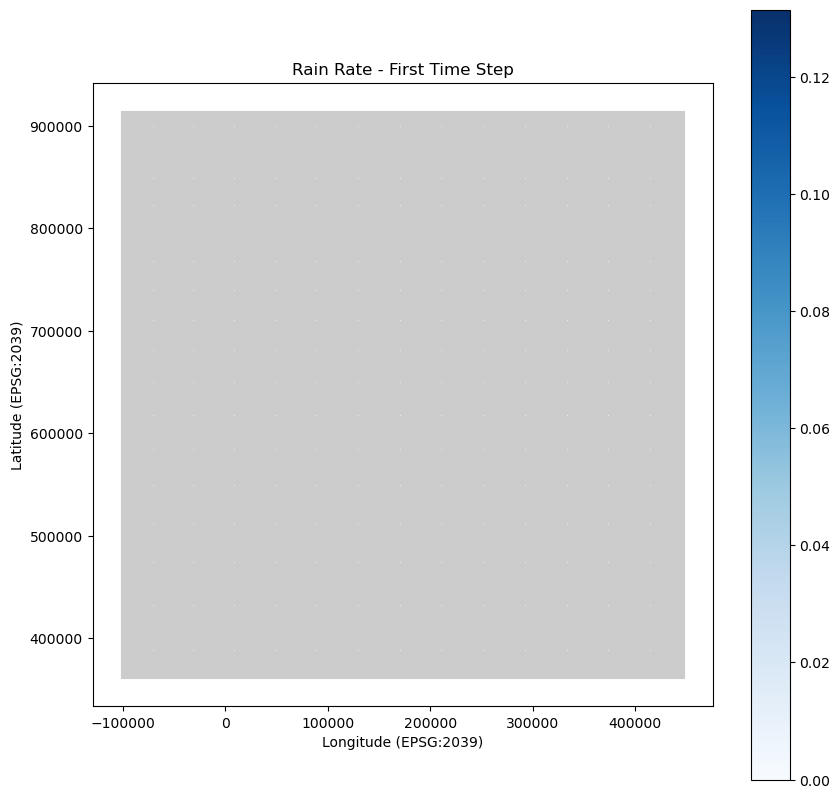

In [20]:
# Example: Access the GeoDataFrame for the first time step
rain_rate_gdf_first_time_step = rain_rate_gdfs[1]

# Plot the GeoDataFrame on a map
fig, ax = plt.subplots(figsize=(10, 10))
rain_rate_gdf_first_time_step.plot(column='rain_value', cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Rain Rate - First Time Step')
ax.set_xlabel('Longitude (EPSG:2039)')
ax.set_ylabel('Latitude (EPSG:2039)')
plt.show()

In [14]:
import h5py
import numpy as np
import pandas as pd
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Polygon
from rasterio.transform import from_origin

# Function to convert a 2D array representing rainfall data into a GeoDataFrame
def rain_array_to_gdf(rain_array, x_coords, y_coords, cellsize):
    """
    Convert a 2D array representing rainfall data into a GeoDataFrame with polygon geometries.
    """
    # Calculate grid dimensions
    nrows, ncols = rain_array.shape
    # Initialize a list to store geometries
    geometries = []
    # Iterate over rows
    for i in range(nrows):
        # Iterate over columns
        for j in range(ncols):
            # Get rain value
            rain_value = rain_array[i, j]
            # Calculate the coordinates of the cell
            x_min = x_coords[j]
            x_max = x_min + cellsize
            y_min = y_coords[i]
            y_max = y_min - cellsize
            # Create a polygon geometry
            polygon = Polygon([(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)])
            # Append to the list of geometries
            geometries.append((rain_value, polygon))
    # Create a GeoDataFrame
    radar_gdf = gpd.GeoDataFrame(geometries, columns=['rain_value', 'geometry'])
    # Replace NaN with 0
    radar_gdf['rain_value'].fillna(0, inplace=True)
    # Set the coordinate reference system to ITM
    radar_gdf.crs = 'epsg:2039'
    
    return radar_gdf

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'

# Read the .mat file
with h5py.File(mat_path, 'r') as file:
    # Extract data
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    
    # Print available keys
    print("Keys: %s" % file.keys())

# Define the coordinate reference system transformation using pyproj.Transformer
transformer = Transformer.from_crs("epsg:4326", "epsg:2039", always_xy=True)
lon_transformed, lat_transformed = transformer.transform(lon_data, lat_data)

# Ensure the transformed coordinates are correctly reshaped
lon_transformed = lon_transformed.reshape(lon_data.shape)
lat_transformed = lat_transformed.reshape(lat_data.shape)

# Define the cell size
cellsize = 1000  # Assuming a cell size of 1000 meters

# Create a GeoDataFrame for each time step
rain_rate_gdfs = [rain_array_to_gdf(rain_rate_data[t, :, :], lon_transformed[0, :], lat_transformed[:, 0], cellsize) for t in range(5)]

# Example: Access the GeoDataFrame for the first time step
rain_rate_gdf_first_time_step = rain_rate_gdfs[0]
print(rain_rate_gdf_first_time_step)


Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>
        rain_value                                           geometry
0              0.0  POLYGON ((-101998.368 362321.327, -100998.368 ...
1              0.0  POLYGON ((-100997.332 362321.327, -99997.332 3...
2              0.0  POLYGON ((-99996.272 362321.327, -98996.272 36...
3              0.0  POLYGON ((-98995.260 362321.327, -97995.260 36...
4              0.0  POLYGON ((-97997.203 362321.327, -96997.203 36...
...            ...                                                ...
302495         0.0  POLYGON ((442725.301 914466.075, 443725.301 91...
302496         0.0  POLYGON ((443722.420 914466.075, 444722.420 91...
302497         0.0  POLYGON ((444722.498 914466.075, 445722.498 91...
302498         0.0  POLYGON ((445722.618 914466.075, 446722.618 91...
302499         0.0  POLYGON ((446722.732 914466.075, 447722.732 91...

[302500 rows x 2 columns]


,rain_value,geometry
0,0.0,"POLYGON ((-101998.368 362321.327, -100998.368 ..."
1,0.0,"POLYGON ((-100997.332 362321.327, -99997.332 3..."
2,0.0,"POLYGON ((-99996.272 362321.327, -98996.272 36..."
3,0.0,"POLYGON ((-98995.260 362321.327, -97995.260 36..."
4,0.0,"POLYGON ((-97997.203 362321.327, -96997.203 36..."
...,...,...
302495,0.0,"POLYGON ((442725.301 914466.075, 443725.301 91..."
302496,0.0,"POLYGON ((443722.420 914466.075, 444722.420 91..."
302497,0.0,"POLYGON ((444722.498 914466.075, 445722.498 91..."
302498,0.0,"POLYGON ((445722.618 914466.075, 446722.618 91..."


In [6]:
lon_transformed

array([[-101998.36836547, -100997.33230774,  -99996.27238893, ...,
         444722.49762585,  445722.61828718,  446722.7317274 ],
       [-102005.84641088, -101004.8856207 , -100006.91572458, ...,
         444735.39620568,  445735.43805786,  446735.45582524],
       [-102016.30118619, -101015.39168886, -100014.5419514 , ...,
         444748.30034004,  445748.24657649,  446748.19404633],
       ...,
       [-106185.16905624, -105165.52551353, -104145.86601036, ...,
         451263.39178121,  452284.81816821,  453303.4440702 ],
       [-106192.11639115, -105172.55335603, -104153.01844624, ...,
         451274.82863163,  452293.33362399,  453314.67125317],
       [-106199.00208554, -105179.56376885, -104157.34134044, ...,
         451286.262134  ,  452304.67824218,  453325.90571442]])

In [5]:
# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'

# Read the .mat file
with h5py.File(mat_path, 'r') as file:
    # Extract data
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    
    # Print available keys
    print("Keys: %s" % file.keys())

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


In [9]:
lat_data

array([[29.307156, 29.307484, 29.307823, ..., 29.318806, 29.318504,
        29.31821 ],
       [29.316116, 29.316448, 29.316776, ..., 29.327774, 29.327469,
        29.327179],
       [29.32507 , 29.325413, 29.32574 , ..., 29.336735, 29.336433,
        29.336136],
       ...,
       [34.258247, 34.258614, 34.258987, ..., 34.271023, 34.270702,
        34.270382],
       [34.267376, 34.26775 , 34.26812 , ..., 34.280163, 34.279842,
        34.27952 ],
       [34.276516, 34.276886, 34.277252, ..., 34.2893  , 34.28897 ,
        34.288647]], dtype=float32)

In [2]:
# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\future\WRFrain_PGW_V3_HPE01.mat'

# Read the .mat file
with h5py.File(mat_path, 'r') as file:
    # Extract data
    rain_rate_data = np.array(file['rainRatePGW'])
    rain_total_data = np.array(file['totalRainPGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList']).flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    
    # Print available keys
    print("Keys: %s" % file.keys())

# Store the data in a dictionary
data_dict = {
    'rainRatePGW': rain_rate_data,
    'totalRainPGW' : rain_total_data,
    'lat': lat_data,
    'lon': lon_data,
    'timesList': time_data,
    'time_vector': time_vector
}

# # Define the path to save the pickle file
# pickle_directory = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\future'
# pickle_filename = os.path.splitext(os.path.basename(mat_path))[0] + '.pkl'
# pickle_path = os.path.join(pickle_directory, pickle_filename)

# # Save the dictionary as a pickle file
# with open(pickle_path, 'wb') as file:
#     pickle.dump(data_dict, file)

# print(f'Data has been saved to {pickle_path}')


Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


In [ ]:
crs = 'epsg:2039'

In [2]:
# Define the path to the directory containing .mat files
mat_directory = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\matfiles\historical'
pickle_directory = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical'

# Create the pickle directory if it does not exist
os.makedirs(pickle_directory, exist_ok=True)

# Iterate through all .mat files in the directory
for mat_filename in os.listdir(mat_directory):
    if mat_filename.endswith('.mat'):
        mat_path = os.path.join(mat_directory, mat_filename)
        
        # Read the .mat file
        with h5py.File(mat_path, 'r') as file:
#             Extract data
            rain_rate_data = np.array(file['rainRate'])
            rain_total_data = np.array(file['totalRain'])
            lat_data = np.array(file['lat'])
            lon_data = np.array(file['lon'])
            time_data = np.array(file['timesList']).flatten()
            time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
            
#             Print available keys (optional)
            print(f"Keys for {mat_filename}: {list(file.keys())}")
        
        # Store the data in a dictionary
        data_dict = {
            'rainRatePGW': rain_rate_data,
            'totalRainPGW' : rain_total_data,
            'lat': lat_data,
            'lon': lon_data,
            'timesList': time_data,
            'time_vector': time_vector
        }
        
        # Define the path to save the pickle file
        pickle_filename = os.path.splitext(mat_filename)[0] + '.pkl'
        pickle_path = os.path.join(pickle_directory, pickle_filename)
        
        # Save the dictionary as a pickle file
        with open(pickle_path, 'wb') as file:
            pickle.dump(data_dict, file)
        
        print(f'Data from {mat_filename} has been saved to {pickle_path}')


Keys for WRFrain_noPGW_HPE01.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE01.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE01.pkl
Keys for WRFrain_noPGW_HPE02.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE02.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE02.pkl
Keys for WRFrain_noPGW_HPE03.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE03.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE03.pkl
Keys for WRFrain_noPGW_HPE04.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE04.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE04.pkl
Keys for WRFrain_noPGW_HPE05.mat: ['lat', 'lon', 'rainRa

Keys for WRFrain_noPGW_HPE36.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE36.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE36.pkl
Keys for WRFrain_noPGW_HPE37.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE37.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE37.pkl
Keys for WRFrain_noPGW_HPE38.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE38.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE38.pkl
Keys for WRFrain_noPGW_HPE39.mat: ['lat', 'lon', 'rainRate', 'timesList', 'totalRain']
Data from WRFrain_noPGW_HPE39.mat has been saved to \\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\pickles\historical\WRFrain_noPGW_HPE39.pkl
Keys for WRFrain_noPGW_HPE40.mat: ['lat', 'lon', 'rainRa

In [4]:
rain_total_data

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.26510947e-04, 9.38357119e-05, ...,
        6.15607656e-04, 1.61114645e-03, 0.00000000e+00],
       [0.00000000e+00, 1.44304024e-04, 9.81279875e-05, ...,
        1.11134803e-04, 7.16032220e-04, 0.00000000e+00],
       ...,
       [0.00000000e+00, 3.06953239e+00, 2.88411020e+00, ...,
        3.87749719e+00, 4.05523824e+00, 0.00000000e+00],
       [0.00000000e+00, 3.02318169e+00, 2.86982179e+00, ...,
        3.44060517e+00, 3.68517423e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

## single plot visualization

Keys: <KeysViewHDF5 ['lat', 'lon', 'rainRatePGW', 'timesList', 'totalRainPGW']>


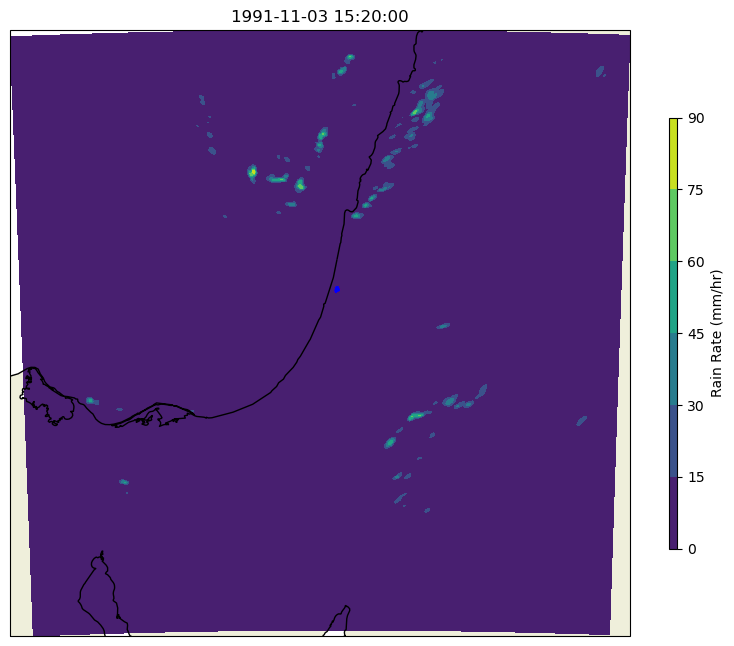

In [165]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList'])
    time_data = mat_data['timesList'].flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')
    print("Keys: %s" % file.keys())
# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

time_slice = 200
# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the rain data
rain_plot = ax.contourf(lon_data, lat_data, rain_data[time_slice,:,:], cmap='viridis', transform=ccrs.PlateCarree())

# Add a color bar
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())

# Add titles and labels
plt.title(f'{time_vector[time_slice]}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Show the plot
plt.show()


# gif visualization

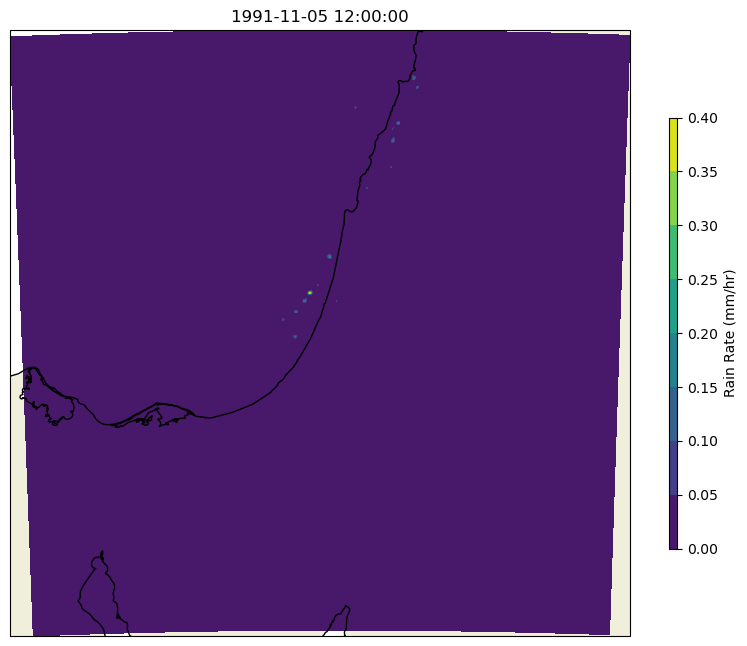

In [170]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib.animation as animation

# Define the path to the .mat file
mat_path = r'\\vscifs.cc.huji.ac.il\hydrolab\hydrolab\home\Raz\WRF\future\WRFrain_PGW_V3_HPE01.mat'
# Define the path to the shapefiles
raanana_shpfile = r'D:\Development\RESEARCH\Raanana\gis\GIS\watershead_for_radar\Raanana_wsp.shp'
raanana_basins_shapefile = r'D:\Development\RESEARCH\Raanana\gis\GIS\28_subcatchments\raanana_28_subcatchments.shp'

# Open the file and load the data
with h5py.File(mat_path, 'r') as file:
    rain_data = np.array(file['rainRatePGW'])
    lat_data = np.array(file['lat'])
    lon_data = np.array(file['lon'])
    time_data = np.array(file['timesList'])
    time_data = mat_data['timesList'].flatten()
    time_vector = pd.to_datetime(time_data - 719529, unit='D').round('1min')

# Load the shapefiles using Geopandas and keep only the geometry column
raanana_watershed = gpd.read_file(raanana_shpfile)[['geometry']]
raanana_basins = gpd.read_file(raanana_basins_shapefile)[['geometry']]

# Reproject the shapefiles from ITM to WGS 84
raanana_watershed = raanana_watershed.to_crs(epsg=4326)
raanana_basins = raanana_basins.to_crs(epsg=4326)

# Create a plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add features to the map
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)

# Initialize the plot with the first frame
rain_plot = ax.contourf(lon_data, lat_data, rain_data[0, :, :], cmap='viridis', transform=ccrs.PlateCarree())
cbar = plt.colorbar(rain_plot, orientation='vertical', pad=0.05, aspect=50, shrink=0.7)
cbar.set_label('Rain Rate (mm/hr)')

# Plot the shapefiles
raanana_watershed.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())
raanana_basins.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1, transform=ccrs.PlateCarree())


plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Function to update the plot for each frame
def update(frame):
    global rain_plot
    for c in rain_plot.collections:
        c.remove()
    rain_plot = ax.contourf(lon_data, lat_data, rain_data[frame, :, :], cmap='viridis', transform=ccrs.PlateCarree())
    plt.title(f'{time_vector[frame]}')
# Create the animation for the first 5 frames
ani = animation.FuncAnimation(fig, update, frames=range(rain_data.shape[0]), repeat=True)
# ani = animation.FuncAnimation(fig, update, frames=range(10), repeat=True)

# Save the animation as a GIF using PillowWriter
ani.save('rain_animation_first5.gif', writer='pillow', fps=2)

# Show the plot (optional)
plt.show()
